# Метод распространения меток (LPA)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 3: Выделение сообществ"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.label_propagation.label_propagation_communities.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_numpy_array.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.density.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.partition_quality.html

## Вопросы для совместного обсуждения

1\. Обсудите принцип работы LPA и реализацию этого алгоритма в `networkx.`

## Задачи для самостоятельного решения

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from networkx.algorithms.community.label_propagation import label_propagation_communities
from networkx.algorithms.community.quality import modularity, partition_quality

<p class="task" id="1"></p>

1\. Загрузите граф карате-клуба и выделите в нем сообщества с помощью реализации алгоритма распространения меток из `networkx`.
Визуализируйте полученный результат. Для визуализации выберите несколько цветов (в соответствии с количеством выделенных сообществ) и раскрасьте узлы и связи в рамках одного сообщества этими цветами. Связи между узлами, состоящими в разных сообществах, отрисуйте черным цветом. 

- [ ] Проверено на семинаре

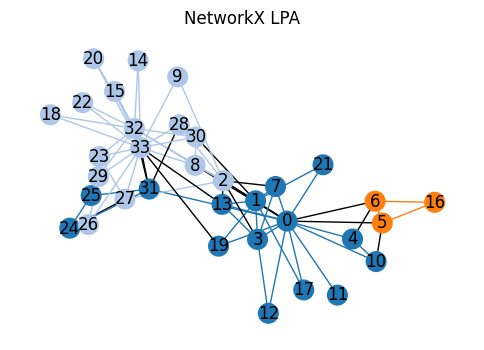

In [2]:
g = nx.karate_club_graph()

def d(g, c, t):
    cm = plt.get_cmap('tab20')
    nc =[]
    for n in g.nodes():
        for i, s in enumerate(c):
            if n in s:
                nc.append(cm(i))
                break
    ec =[]
    for u, v in g.edges():
        s = False
        for i, cm_set in enumerate(c):
            if u in cm_set and v in cm_set:
                ec.append(cm(i))
                s = True
                break
        if not s:
            ec.append('black')
    plt.figure(figsize=(6, 4))
    plt.title(t)
    nx.draw(g, node_color=nc, edge_color=ec, node_size=200, with_labels=True)
    plt.show()

c0 = list(label_propagation_communities(g))
d(g, c0, "NetworkX LPA")

<p class="task" id="2"></p>

2\. Реализуйте синхронный алгоритм распространения меток. В синхронном варианте алгоритма для выбора новой метки узла используются метки соседей с предыдущей итерации. Если среди меток соседей есть несколько вариантов с одинаковой максимальной частотой, то метка выбирается случайным образом. Алгоритм прекращает работу, когда на очередной итерации не была изменена метка ни одного узла. Визуализируйте пошаговую динамику распространения меток и итоговое разбиение сети аналогично предыдущей задаче.

- [ ] Проверено на семинаре

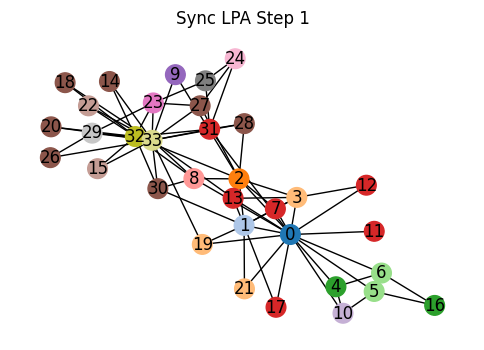

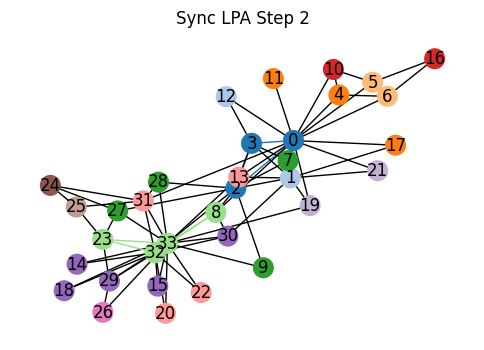

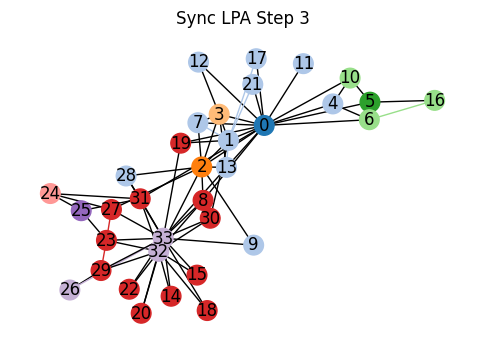

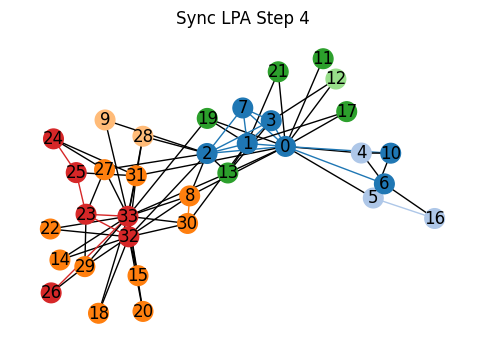

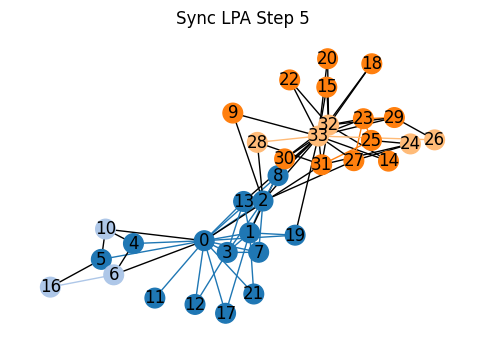

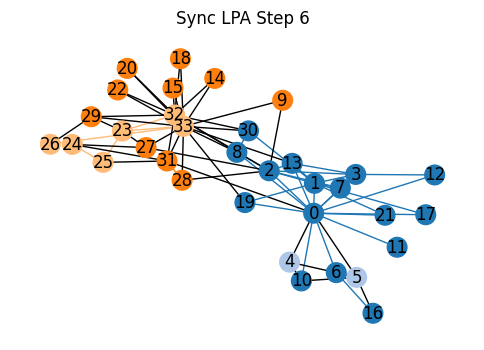

In [3]:
l1 = {n: n for n in g.nodes()}
i = 1
while True:
    n1 = {}
    for n in g.nodes():
        b = [l1[x] for x in g.neighbors(n)]
        m = max([b.count(x) for x in set(b)])
        f =[x for x in set(b) if b.count(x) == m]
        n1[n] = random.choice(f)
    
    v = {}
    for k, val in n1.items():
        v.setdefault(val, set()).add(k)
    c1 = list(v.values())
    
    d(g, c1, f"Sync LPA Step {i}")
    i += 1
    if n1 == l1 or i > 6:
        break
    l1 = n1

<p class="task" id="3"></p>

3\. Реализуйте асинхронный алгоритм распространения меток. В асинхронном варианте алгоритма для выбора новой метки узла используются в том числе метки соседей с текущей итерации алгоритма. Визуализируйте пошаговую динамику распространения меток и итоговое разбиение сети аналогично предыдущей задаче.

- [ ] Проверено на семинаре

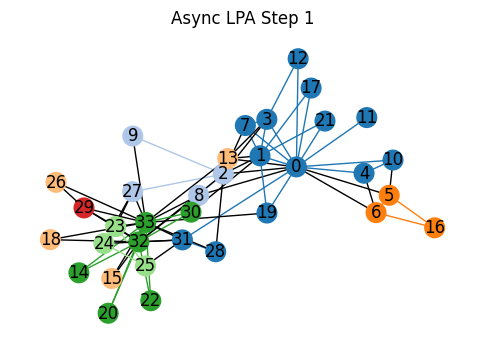

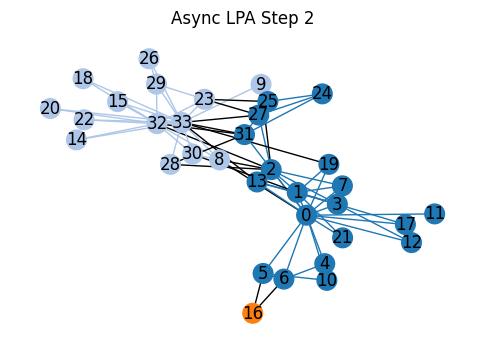

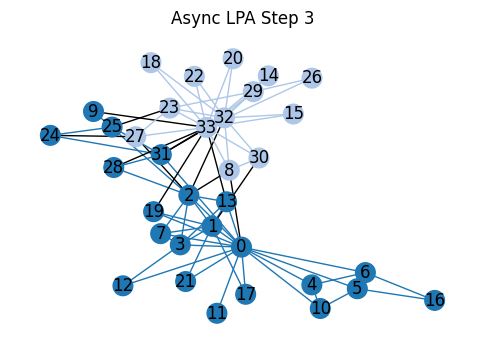

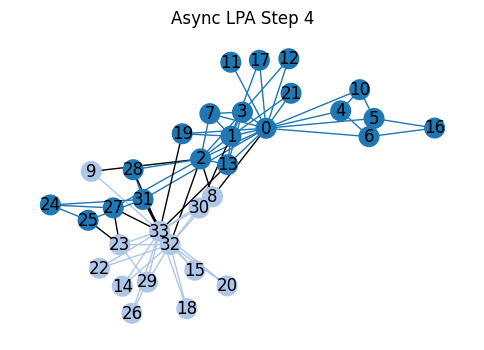

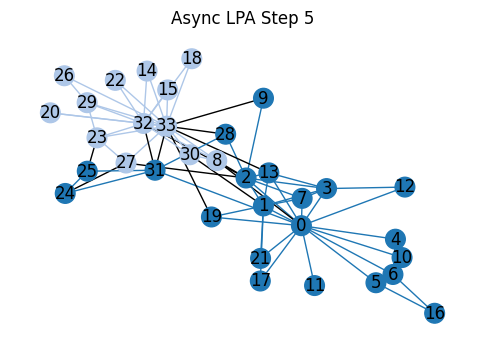

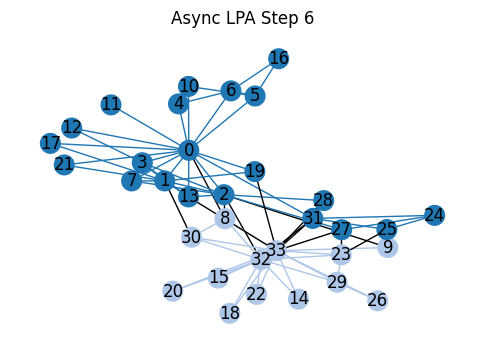

In [4]:
l2 = {n: n for n in g.nodes()}
j = 1
while True:
    f1 = False
    nd = list(g.nodes())
    random.shuffle(nd)
    for n in nd:
        b = [l2[x] for x in g.neighbors(n)]
        m = max([b.count(x) for x in set(b)])
        f = [x for x in set(b) if b.count(x) == m]
        nl = random.choice(f)
        if l2[n] != nl:
            f1 = True
            l2[n] = nl
    
    v = {}
    for k, val in l2.items():
        v.setdefault(val, set()).add(k)
    c2 = list(v.values())
    
    d(g, c2, f"Async LPA Step {j}")
    j += 1
    if not f1 or j > 6:
        break

<p class="task" id="4"></p>

4\. Используя собственную реализацию LPA, разбейте граф карате-клуба на сообщества `N=10` раз. Создайте двумерный массив `freqs` размера `MxM` (`M` - количество узлов в графе), где `freqs[i, j]` показывает, как часто узлы `i` и `j` оказывались в одном сообществе. 

Создайте граф, в котором между узлами `i` и `j` существует связь только тогда, когда `freqs[i, j] >= 8`. Получите компоненты связности данного графа. Интерпретируя данные компоненты связности как сообщества в исходном графе, визуализируйте полученное разбиение карате-клуба (оригинального графа) аналогично предыдущим заданиям.


- [ ] Проверено на семинаре

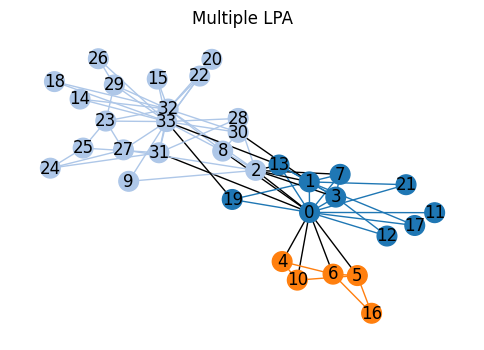

In [5]:
def a():
    l = {n: n for n in g.nodes()}
    for _ in range(20):
        f = False
        nd = list(g.nodes())
        random.shuffle(nd)
        for n in nd:
            b = [l[x] for x in g.neighbors(n)]
            m = max([b.count(x) for x in set(b)])
            v =[x for x in set(b) if b.count(x) == m]
            nl = random.choice(v)
            if l[n] != nl:
                f = True
                l[n] = nl
        if not f:
            break
    r = {}
    for k, val in l.items():
        r.setdefault(val, set()).add(k)
    return list(r.values())

s = len(g.nodes())
fq = np.zeros((s, s))
for _ in range(10):
    cp = a()
    for c in cp:
        sl = list(c)
        for x in range(len(sl)):
            for y in range(x+1, len(sl)):
                fq[sl[x], sl[y]] += 1
                fq[sl[y], sl[x]] += 1

g3 = nx.Graph()
g3.add_nodes_from(g.nodes())
for x in range(s):
    for y in range(x+1, s):
        if fq[x, y] >= 8:
            g3.add_edge(x, y)

c3 = list(nx.connected_components(g3))
d(g, c3, "Multiple LPA")

<p class="task" id="5"></p>

5\. Оформите результаты работы алгоритмов в виде таблицы

| Алгоритм                      | Средняя плотность сообществ | Модулярность | Покрытие | Эффективность |
|-------------------------------|-----------------------------|--------------|----------|----------|
| Синхронный LPA             |                             |              |          |          |
| Асинхронный LPA                     |                             |              |          |          |
| Множественный LPA                     |                             |              |          |          |

Для представления данных в табличном виде используйте `pandas`.  Все расчеты метрик при решении этой задачи выполните повторно.

- [ ] Проверено на семинаре

In [6]:
def mt(c):
    ad = np.mean([nx.density(g.subgraph(s)) for s in c if len(s) > 1] or[0])
    md = modularity(g, c)
    pq = partition_quality(g, c)
    return round(ad, 2), round(md, 2), round(pq[0], 2), round(pq[1], 2)

r = [["Синхронный LPA", *mt(c1)],
    ["Асинхронный LPA", *mt(c2)],
    ["Множественный LPA", *mt(c3)]
]

df = pd.DataFrame(r, columns=[
    "Алгоритм", 
    "Средняя плотность сообществ", 
    "Модулярность", 
    "Покрытие", 
    "Эффективность"
])
df

,Алгоритм,Средняя плотность сообществ,Модулярность,Покрытие,Эффективность
0,Синхронный LPA,0.17,0.14,0.47,0.67
1,Асинхронный LPA,0.25,0.31,0.83,0.58
2,Множественный LPA,0.41,0.36,0.82,0.69
